In [1]:
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Track data loading
import psutil
import time

# Save&Load results
import pickle

In [2]:
import networkx as nx

import pandas as pd
import seaborn as sns

# 1. Load Data

In [3]:
st = time.time()

with open("data/graphs/G_filtered.gpickle", 'rb') as f:
    G_filtered = pickle.load(f)

et = time.time()
elapsed_time = et - st

print('Execution time:', elapsed_time/60, 'mins')
# Getting % usage of virtual_memory ( 3rd field)
print('RAM memory % used:', psutil.virtual_memory()[2])
# Getting usage of virtual_memory in GB ( 4th field)
print('RAM Used (GB):', psutil.virtual_memory()[3]/1000000000)

Execution time: 1.4735087752342224 mins
RAM memory % used: 6.2
RAM Used (GB): 22.301335552


In [4]:
st = time.time()

with open("data/graphs/G_original.gpickle", 'rb') as f:
    G_original = pickle.load(f)

et = time.time()
elapsed_time = et - st

print('Execution  time:', elapsed_time/60, 'mins')
# Getting % usage of virtual_memory ( 3rd field)
print('RAM memory % used:', psutil.virtual_memory()[2])
# Getting usage of virtual_memory in GB ( 4th field)
print('RAM Used (GB):', psutil.virtual_memory()[3]/1000000000)

Execution time: 18.504926200707754 mins
RAM memory % used: 59.9
RAM Used (GB): 237.95324928


# 2. Alternative Def of "Creators" & "Consumers"

Using metrics used in ["The voice of few, the opinions of many: evidence of social biases in Twitter COVID-19 fake news sharing"](https://royalsocietypublishing.org/rsos/article/9/10/220716/96291/The-voice-of-few-the-opinions-of-many-evidence-of) (Castioni et al. 2022)

In [6]:
def rate_fakeNewCreators(G):
    newsCategories_dict = nx.get_edge_attributes(G, "newsCategories")
    nodes_list = list(G.nodes)
    
    rate_dict = {}
    for node in nodes_list:
        if len(G.out_edges(node)) > 0:
            newsCreate_categoryArr = np.concatenate(np.array([newsCategories_dict[edge] for edge in list(G.out_edges(node))]), axis = None)
            newsCreate_fakeCount = np.sum(newsCreate_categoryArr == 0) + np.sum(newsCreate_categoryArr == 1) + np.sum(newsCreate_categoryArr == 2)
            rate = newsCreate_fakeCount/len(newsCreate_categoryArr)
            rate_dict.update({node:rate})
        else:
            rate_dict.update({node:float('nan')})

    return rate_dict    

- filtered network

In [7]:
st = time.time()

filtered_rate_dict = rate_fakeNewCreators(G_filtered)

et = time.time()
elapsed_time = et - st

print('Execution time:', elapsed_time/60, 'mins')
# Getting % usage of virtual_memory ( 3rd field)
print('RAM memory % used:', psutil.virtual_memory()[2])
# Getting usage of virtual_memory in GB ( 4th field)
print('RAM Used (GB):', psutil.virtual_memory()[3]/1000000000)

Execution time: 0.5191862980524699 mins
RAM memory % used: 59.8
RAM Used (GB): 237.474562048


In [8]:
filtered_rate_arr = np.array(list(filtered_rate_dict.values()))
filtered_nan_mask = np.isnan(filtered_rate_arr)

In [9]:
np.sum(np.isnan(filtered_rate_arr)), len(filtered_rate_arr[~filtered_nan_mask])

(67330, 700223)

- original network

In [10]:
st = time.time()

original_rate_dict = rate_fakeNewCreators(G_original)

et = time.time()
elapsed_time = et - st

print('Execution time:', elapsed_time/60, 'mins')
# Getting % usage of virtual_memory ( 3rd field)
print('RAM memory % used:', psutil.virtual_memory()[2])
# Getting usage of virtual_memory in GB ( 4th field)
print('RAM Used (GB):', psutil.virtual_memory()[3]/1000000000)

Execution time: 12.337005396684011 mins
RAM memory % used: 60.2
RAM Used (GB): 239.296806912


In [11]:
original_rate_arr = np.array(list(original_rate_dict.values()))
original_nan_mask = np.isnan(original_rate_arr)

In [12]:
np.sum(np.isnan(original_rate_arr)), len(original_rate_arr[~original_nan_mask])

(746895, 13201264)

- filtered vs original

In [13]:
np.sum(filtered_rate_arr[~filtered_nan_mask] > 0.2), np.sum(filtered_rate_arr[~filtered_nan_mask] > 0.2)/len(filtered_rate_arr)

(97053, 0.1264446885101094)

In [14]:
np.sum(original_rate_arr[~original_nan_mask] > 0.2), np.sum(original_rate_arr[~original_nan_mask] > 0.2)/len(original_rate_arr)

(1151226, 0.08253605368278351)

In [15]:
x_thresholds = np.arange(0, 1.01, 0.05); 
y_percent_filtered = np.array([np.sum(filtered_rate_arr[~filtered_nan_mask] > x)/len(filtered_rate_arr) for x in x_thresholds])
y_percent_original = np.array([np.sum(original_rate_arr[~original_nan_mask] > x)/len(original_rate_arr) for x in x_thresholds])

In [16]:
x_thresholds

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [17]:
y_percent_filtered

array([0.2908151 , 0.24525733, 0.20184925, 0.16567064, 0.12644469,
       0.0965093 , 0.08349912, 0.07204844, 0.06008315, 0.0545617 ,
       0.04382629, 0.0416766 , 0.03672189, 0.03487056, 0.03262967,
       0.02941556, 0.02759028, 0.0264998 , 0.02533376, 0.02463283,
       0.        ])

In [18]:
y_percent_original

array([0.13703278, 0.12354111, 0.10990239, 0.09721606, 0.08253605,
       0.0711448 , 0.06699271, 0.05711765, 0.05429161, 0.05324954,
       0.03978547, 0.03961569, 0.03877716, 0.0385962 , 0.03648618,
       0.03573188, 0.03540302, 0.03522615, 0.0350229 , 0.03493687,
       0.        ])

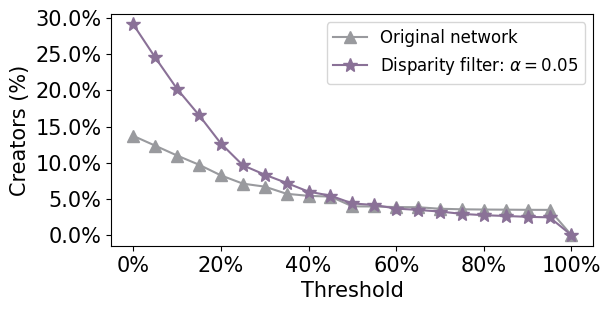

In [19]:
from matplotlib.ticker import PercentFormatter

fig, axs = plt.subplots(figsize = (6,3), constrained_layout = True)

plt.plot(x_thresholds, y_percent_original, marker = '^', markersize = 8, label = "Original network", color = "#999A9E")
plt.plot(x_thresholds, y_percent_filtered, marker = '*', markersize = 10, label = r"Disparity filter: $\alpha = 0.05$", color = "#8A7197")
plt.xlabel("Threshold", fontsize = 15); plt.ylabel("Creators (%)", fontsize = 15)
plt.xticks(fontsize = 15); plt.yticks(fontsize = 15)
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend(fontsize = 12)

fig.savefig('figures/SM_fig10.png', dpi=400, bbox_inches = 'tight')